In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from astropy.time import Time
import astropy.units as u
import rfitools
import numba as nb
import importlib
importlib.reload(rfitools)
import time

In [2]:
@nb.njit(parallel=True)
def geo_delay(bls,alt,az):
    npix = alt.shape[0]
    nbl = bls.shape[0] #each row is x, y, z
    print("nbl", nbl, "npix", npix)
    delays = np.empty((nbl,npix),dtype='float64')
    c=299792458
    for pix in nb.prange(npix):
        cos_alt = np.cos(np.pi * alt[pix] / 180)
        sin_alt = np.sin(np.pi * alt[pix] / 180)
        cos_az = np.cos(np.pi * az[pix] / 180)
        sin_az = np.sin(np.pi * az[pix] / 180)
        for bl in range(nbl):
            ea,no,up = bls[bl]
            p = 0
            p += sin_az*cos_alt * ea #east
            p += cos_az*cos_alt * no #north
            p += sin_alt * up #up
            delays[bl, pix] = p/c
    return delays

@nb.njit(parallel=True)
def get_map(data,freqs,delays,npix):
    print(data.shape, freqs.shape, delays.shape)
    map1 = np.zeros(npix, dtype=np.float64)
    nfreq, nbl = data.shape
    N_vis = nfreq * nbl
    for p in nb.prange(npix):
        pixel_sum = 0.
        for f in range(nfreq):
            nu = freqs[f]
            for b in range(nbl):
                tau = delays[p, b] #delay shape is npix, nbl for CPU

                # Calculate the fringe factor for this specific visibility
                fringe = np.exp(2j * np.pi * nu * tau)
                
                # Accumulate the dot product
                pixel_sum += fringe.real * data[f, b].real - fringe.imag * data[f, b].imag
        
        # Calculate the mean and assign to the pixel map
        map1[p] = pixel_sum / N_vis
    return map1

In [73]:
path_data1 = '/home/mohanagr/Jupyter/MARS Fringe analysis (Summer 2025)/vis_dump.npz'
path_data2 = '/scratch/thomasb/vis_dump2.npz'

with np.load(path_data1) as f:
    vis_data =f['vis']
    cnt=f['cnt']
    tstart=f['tstart']
    deltat=f['deltat']
    deltaf=f['deltaf']

In [82]:
#pixel setup
NSIDE = 256
NPIX=hp.nside2npix(NSIDE)
print('NPIX', NPIX)
print("resol", hp.nside2resol(NSIDE,arcmin=True), "npix", NPIX)

#pick time index
t_idx = 0

#first channel is number 360
fstart = 360*250e6/4096
print('fstart', fstart)
print('deltaf', deltaf)
print('deltat', deltat)
#get baselines
nant=7
triu_idx=np.triu_indices(nant,k=1)
nbl = len(triu_idx[0])
#coordinates
coords = {
        0: [79.417161473, -90.767238685, 187.9577], #MARS1
        1: [79.417198047, -90.758739192, 183.0684], #MARS2
        2: [79.388456412, -91.019202963, 25.1938], #CSA
        3: [79.418302573, -90.667395452, 59.6242], #Mars 5
        4: [79.397984238, -90.799842408, 41.6994], #Mars 6
        5: [79.411474117, -90.695266129, 31.6314], #Mars 7
        6: [79.443757694, -90.718202634, 414.9131] #MARS8
    }
antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}

NPIX 786432
resol 13.741945647269624 npix 786432
fstart 21972656.25
deltaf 4768.37158203125
deltat 1.073741824


In [75]:
co_dec,ra = hp.pix2ang(NSIDE,np.arange(NPIX))
dec = np.pi/2-co_dec

obstime=Time(tstart+t_idx*deltat+deltat/2,format="unix",scale="utc")
print(obstime)
ant0=EarthLocation.from_geodetic(lat=coords[0][0], lon=coords[0][1], height=coords[0][2])
coords_pix = SkyCoord(ra=ra*u.rad, dec=dec*u.rad, frame='icrs')
altaz_pix = coords_pix.transform_to(AltAz(location=ant0,obstime=obstime))

ras = ['23h23m27.94s', '19h 59m 28.3566s']
decs = ['58d48m42.4s', "40° 44′ 02.096″"]
coords_src = SkyCoord(ra=ras,dec=decs , frame='icrs') 
altaz_src = coords_src.transform_to(AltAz(location=ant0,obstime=obstime))

1753264834.1802247


In [76]:
bl_enus = rfitools.get_all_bls(coords,np.arange(len(coords)))
delays_pix = geo_delay(bl_enus, altaz_pix.alt.value, altaz_pix.az.value)
delays_src = geo_delay(bl_enus, altaz_src.alt.value, altaz_src.az.value)

(21, 3)
nbl 21 npix 786432
nbl 21 npix 2


In [77]:
# SIMULATED DATA
good_freqs = np.arange(300) * deltaf + fstart #Hz

vis = 66 * np.exp(-2j*np.pi*delays_src[:,0][None,:] * freqs[:,None]) +\
      37 * np.exp(-2j*np.pi*delays_src[:,1][None,:] * freqs[:,None]) #casA 66,000 Jy, cyg A 37,000 Jy
print('vis shape', vis.shape)

delaysT = delays_pix[:,:].T.copy() #exclude MARS1-2
data = vis[:,].copy()

vis shape (103, 21)


In [ ]:
# REAL DATA
freqs = np.arange(vis_data.shape[1]) * deltaf + fstart
print('freqs shape', freqs.shape)

good_freq_idxs = np.bitwise_and.reduce(cnt[t_idx,:,1:]>0, axis=1)
print('good freq indices', good_freq_idxs.shape)
good_freqs = freqs[good_freq_idxs].copy()
print('good freqs', good_freqs.shape)


delaysT = delays_pix[1:, :].T.copy()
data = vis_data[t_idx, good_freq_idxs, 1:].copy()

freqs shape (410,)
good freq indices (410,)
good freqs (334,)


In [79]:
t1=time.time()
map = get_map(data, good_freqs, delaysT,NPIX)
t2=time.time()
print(t2-t1)

(334, 20) (334,) (786432, 20)


34.26142978668213


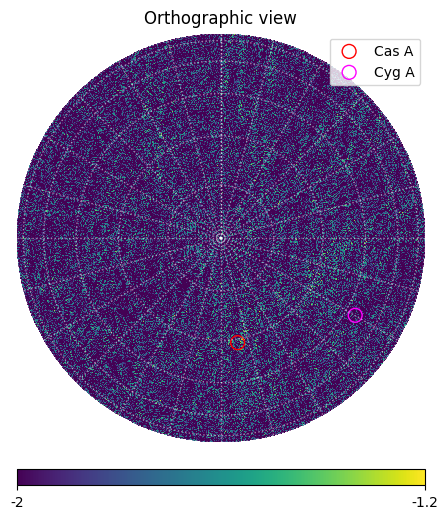

In [84]:
bw=len(freqs)*deltaf
hp.orthview(np.log10(np.abs(map)),min=-2,max=-1.2,rot=(0,90),half_sky=True)
hp.graticule(dpar=15,  dmer=15, color='white', alpha=0.5, ls=':')

hp.projscatter(coords_src[0].ra.deg, coords_src[0].dec.deg, lonlat=True, coord='C', 
                marker='o',       # Circle marker
                facecolors='none',# Hollow circle
                edgecolors='red', # Red outline
                s=100,            # Size of the circle
                lw=1,             # Line width
                label='Cas A')

hp.projscatter(coords_src[1].ra.deg, coords_src[1].dec.deg, lonlat=True, coord='C', 
                marker='o',       # Circle marker
                facecolors='none',# Hollow circle
                edgecolors='magenta', # Red outline
                s=100,            # Size of the circle
                lw=1,             # Line width
                label='Cyg A')

plt.legend()
plt.show()